In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import sys; sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/lib') # add library path

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from variable_print import p,ps,pst
from gridworld import GridworldEnv
#from tensorized_dp import TensorDP
from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

# `GridWorld` 초기화하기

가로로 `nx` 개, 세로로 `ny` 개의 칸을 가진 `GridworldEnv`를 만듭니다!

In [4]:
nx = 5
ny = 5
env = GridworldEnv([ny, nx])

# 가치 반복(Value Iteration)



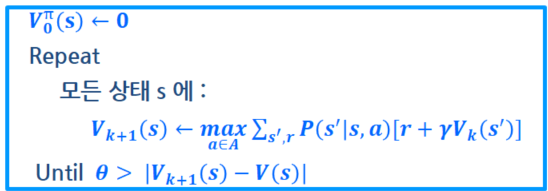

```    python
def value_iteration(self, v_init=None, compute_pi=False):
    ...
    info = dict()
    v_old = np.zeros(self.ns)
    while True:
        # Bellman optimality backup operator 적용
        #(s,)     <- ((a,s) + gamma * (a,s,s') o (s,)):(a,s).max(0)    
        v_improved = (self.R.T + self.gamma * self.P.dot(v_old)).max(axis=0)
        info['v'].append(v_improved)

        if compute_pi:
            # compute policy from v
            # 1) Compute v -> q
            # (a,s) <- (a,s)+ gamma * (a,s,s') o ((s,))
            q_pi = (self.R.T + self.gamma * self.P.dot(v_improved))

            # 2) Construct greedy policy
            # (s,a) <- (s, argmax_a)=1
            pi = np.zeros_like(self.policy) #(s,a)<- 0
            pi[np.arange(q_pi.shape[1]), q_pi.argmax(axis=0)] = 1 #(s, argmax_a)<-1  
            info['pi'].append(pi)
        # check convergence
        policy_gap = np.linalg.norm(v_improved - v_old)

        if policy_gap <= 1e-5 : break
        else:                   v_old = v_improved
    return info #{v,pi,converge}
```    

In [5]:
class TensorDP:
    def __init__(self, gamma=1.0, error_tol=1e-5):
        self.gamma = gamma
        self.error_tol = error_tol

        # Following attributes will be set after call "set_env()"
        self.env = None  # environment
        self.policy = None  # policy
        self.ns = None  # Num. states
        self.na = None  # Num. actions
        self.P = None  # Transition tensor
        self.R = None  # Reward tensor

    def set_env(self, env, policy=None):
        self.env = env
        if policy is None:
            self.policy = np.ones([env.nS, env.nA]) / env.nA

        self.ns = env.nS
        self.na = env.nA
        self.P = env.P_tensor  # Rank 3 tensor (a,s,s'):(4,25,25)
        self.R = env.R_tensor  # Rank 2 tensor (s,a):(25,4)
        print(f"Environment : #state = {env.nS} , #actions = {env.nA} ")

    def reset_policy(self): #(s,a)
        self.policy = np.ones([self.ns, self.na]) / self.na

    def set_policy(self, policy):
        assert self.policy.shape == policy.shape
        self.policy = policy

    def get_r_pi(self, policy): #(s,)<-(s,a)*(s,a)
        r_pi = (policy * self.R).sum(axis=-1)  # *:element-wise
        return r_pi

    def get_p_pi(self, policy):
        p_pi = np.einsum("na,anm->nm", policy, self.P)  # [num. states x num. states]
        return p_pi

    def value_iteration(self, v_init=None, compute_pi=False):
        if v_init is not None:
            v_old = v_init
        else:
            v_old = np.zeros(self.ns)

        info = dict()
        info['v'] = list()
        info['pi'] = list()
        info['converge'] = None

        steps = 0
        converged = False

        while True:
            # Bellman optimality backup
            #(s,)     <- ((a,s) + gamma * (a,s,s') o (s,)):(a,s).max(0)
            v_improved = (self.R.T + self.gamma * self.P.dot(v_old)).max(axis=0)
            info['v'].append(v_improved)

            if compute_pi:
                # compute policy from v
                # 1) Compute v -> q
                # (a,s) <- (a,s)+ gamma * (a,s,s') o ((s,))
                q_pi = (self.R.T + self.gamma * self.P.dot(v_improved))

                # 2) Construct greedy policy
                pi = np.zeros_like(self.policy)
                pi[np.arange(q_pi.shape[1]), q_pi.argmax(axis=0)] = 1
                info['pi'].append(pi)

            steps += 1

            # check convergence
            policy_gap = np.linalg.norm(v_improved - v_old)
            if policy_gap <= self.error_tol:
                if not converged:  # record the first moment of within error tolerance.
                    info['converge'] = steps
                break
            else:
                v_old = v_improved
        return info

In [6]:
dp_agent = TensorDP()
dp_agent.set_env(env)

Environment : #state = 25 , #actions = 4 


## 최적 가치함수 $V^\pi$구하기 : repeat($V_t$$_+$$_1$$\leftarrow T^\pi(V_t)$)
>$T^\pi(V)=max_a(R+\gamma PV)$

### Value $V$ update

In [7]:
v_old = np.zeros(dp_agent.ns)
 #(s,)     <- ((a,s) + gamma * (a,s,s') o (s,)).max(ax=0)
v_improved = (dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_old)).max(axis=0)

ps(dp_agent.R.T,'dp_agent.R.T') #(a,s)<-(s,a)
ps(dp_agent.P.dot(v_old),'P.dot') #(a,s)<-(a,s,s')o(s,)
ps(dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_old),'R+') #(a,s)
ps((dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_old)).max(0),'max(0)') #(s,)

<<dp_agent.R.T>> Shape(4, 25)
<<P.dot>> Shape(4, 25)
<<R+>> Shape(4, 25)
<<max(0)>> Shape(25,)


### V update 시각화  
#### value iteration 과정에서 V(s)의 변화 추적

policy_gap: 4.795831523312719
policy_gap: 4.358898943540674
policy_gap: 3.605551275463989
policy_gap: 2.23606797749979
policy_gap: 0.0


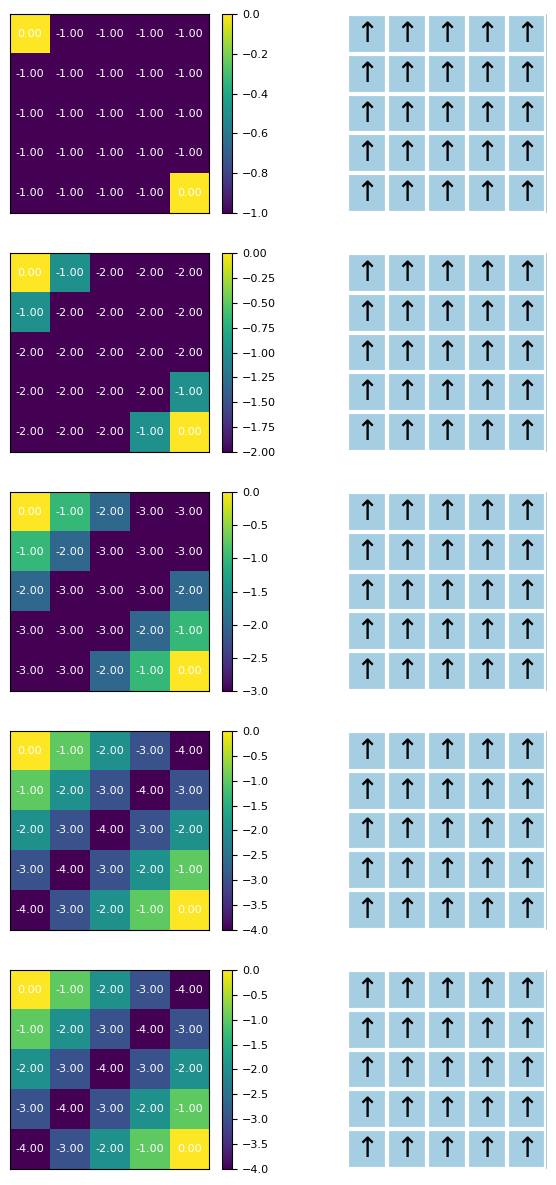

In [8]:
steps = 5
fig, ax = plt.subplots(nrows=steps,ncols=2, figsize=(steps*5*0.3, 5*3))
v_old = np.zeros(dp_agent.ns)
for i in range(steps):
  v_improved = (dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_old)).max(axis=0)
  policy_gap = np.linalg.norm(v_improved - v_old)  # V(s)값이 정책평가 결과,V(s)변화 = 정책변화
  print('policy_gap:',policy_gap)
  v_old = v_improved
  visualize_value_function(ax[i][0],v_improved, nx, ny)
  visualize_policy(ax[i][1], dp_agent.policy, nx, ny)

In [9]:
dp_agent.reset_policy()
info_vi = dp_agent.value_iteration(compute_pi=False) # policy update 하지 않음

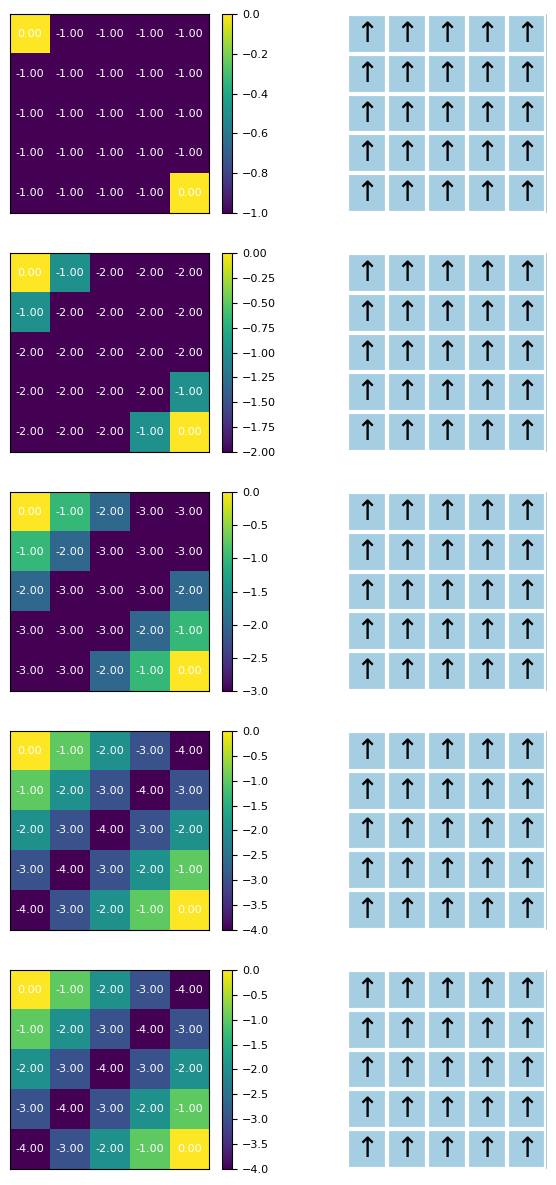

In [10]:
steps = info_vi['converge']

fig, ax = plt.subplots(nrows=steps,ncols=2, figsize=(steps * 5 * 0.3, 5* 3))
for i in range(steps):
    visualize_value_function(ax[i][0],info_vi['v'][i], nx, ny)
    visualize_policy(ax[i][1], dp_agent.policy, nx, ny)
#    visualize_policy(ax[i][1], info_vi['pi'][i], nx, ny) ## policy update되지 않았음

### policy $\pi$ update

In [11]:
v_old = np.zeros(dp_agent.ns)
### V update
#(s,) <- ((a,s) + gamma * (a,s,s') o (s,)).max(0)
v_improved = (dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_old)).max(axis=0)
### pi update
q_pi = (dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_improved)) #(a,s)
pi = np.zeros_like(dp_agent.policy) #(s,a)<- 0
pi[np.arange(q_pi.shape[1]), q_pi.argmax(axis=0)] = 1 #(s, argmax_a)<-1
p(pi) #(s,a)

<<>>:
Shape:(25, 4)
Type: <class 'numpy.ndarray'>
Values: [[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]


### $\pi$ update 시각화

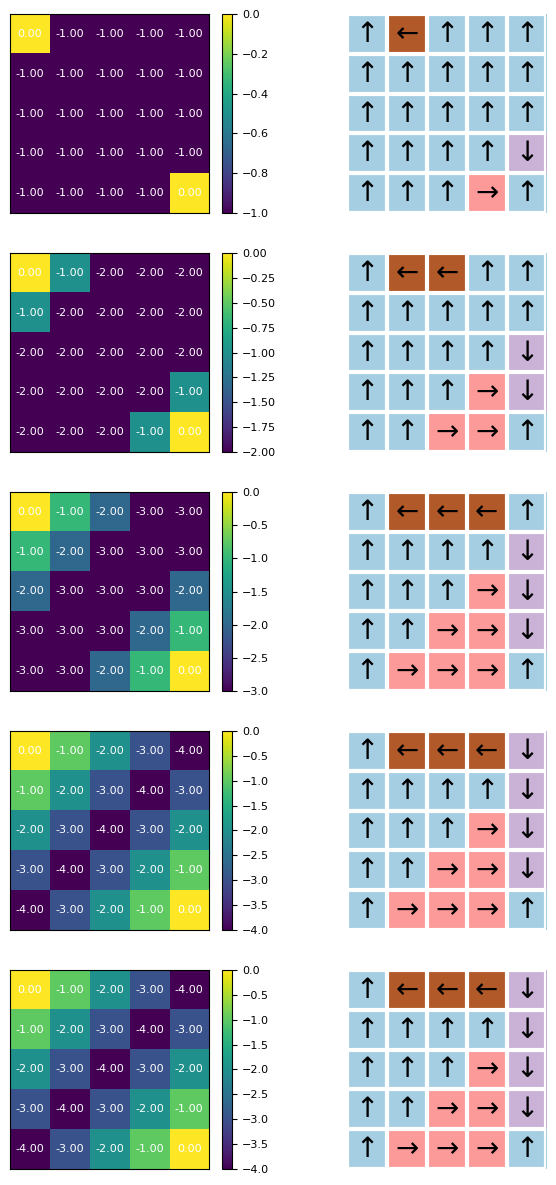

In [12]:
steps = 5
fig, ax = plt.subplots(nrows=steps,ncols=2, figsize=(steps*5*0.3, 5*3))
v_old = np.zeros(dp_agent.ns)
for i in range(steps):
  ### v update
  v_improved = (dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_old)).max(axis=0)
  v_old = v_improved
  ### pi update
  # (a,s) <- (a,s)+ gamma * (a,s,s') o ((s,))
  q_pi = (dp_agent.R.T + dp_agent.gamma * dp_agent.P.dot(v_improved))
  pi = np.zeros_like(dp_agent.policy) #(s,a)<- 0
  pi[np.arange(q_pi.shape[1]), q_pi.argmax(axis=0)] = 1 #(s, argmax_a)=1
  dp_agent.policy = pi
  ### visualize
  visualize_value_function(ax[i][0],v_improved, nx, ny)
  visualize_policy(ax[i][1], dp_agent.policy, nx, ny)

**Agent의 value_iteration 실행 결과 시각화**

In [13]:
dp_agent.reset_policy()
info_vi = dp_agent.value_iteration(compute_pi=True)

In [14]:
info_vi.keys()

dict_keys(['v', 'pi', 'converge'])

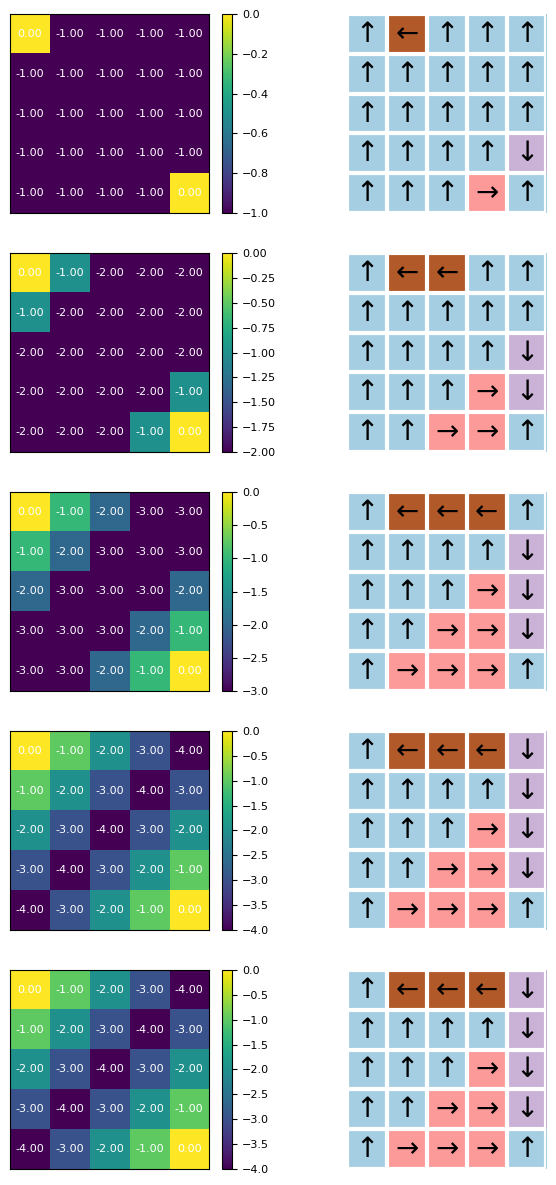

In [15]:
steps = info_vi['converge']

fig, ax = plt.subplots(nrows=steps,ncols=2, figsize=(steps * 5 * 0.3, 5* 3))
for i in range(steps):
    visualize_value_function(ax[i][0],info_vi['v'][i], nx, ny)
    visualize_policy(ax[i][1], info_vi['pi'][i], nx, ny)